In [1]:
from THM_main import Version5_THM_prototype
from iapws import IAPWS97
import numpy as np
from THM_main import plotting
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
# Begining of the script used to test the THM prototype class.

In [2]:
def guess_power_density_sine(Ptot, h, r, num_control_volumes): # New version, supposed to be more accurate but introduced alot of instability in the TH solution
    """
    Compute the power density in a cylinder with a sine-shaped profile along the axial direction.

    Parameters:
    Ptot (float): Total power released in the cylinder [W].
    h (float): Total height of the cylinder [m].
    r (float): Radius of the cylinder [m].
    num_control_volumes (int): Number of control volumes along the z-axis.

    Returns:
    z_values (numpy array): Array of z positions (center of each control volume) along the height of the cylinder.
    power_density (numpy array): Array of power densities corresponding to each control volume.
    q0 (float): The peak power density constant.
    """
    
    # Cross-sectional area of the cylinder
    A_cross_section = np.pi * r**2

    # Function for the power density profile along the axial direction
    def q(z, q0):
        return q0 * np.sin(np.pi * z / h)

    # Calculate q0 to ensure total power matches Ptot
    q0 = Ptot / (A_cross_section * (2 * h / np.pi))  # derived from the integral

    # Compute the boundaries and midpoints of each control volume
    z_boundaries = np.linspace(0, h, num_control_volumes + 1)
    z_values = (z_boundaries[:-1] + z_boundaries[1:]) / 2  # Midpoints of control volumes

    # Compute power density at each midpoint
    power_density = q(z_values, q0)

    return z_values, power_density

In [3]:
compute_case_monophasic = True
if compute_case_monophasic:
    case_name = "genfoam_comparaison_correl"
    #User choice:
    solveConduction = False
    zPlotting = [0.8]

 ########## Thermal hydraulics parameters ##########
    ## Geometric parameters
    canalType = "square" # "square", "cylindrical"
    waterRadius = 1.296e-2 #1.295e-2 # m : ATRIUM10 pincell pitch   0.0126 #
    fuelRadius = 0.4435e-2 # m : fuel rod radius
    gapRadius = 0.4520e-2 # m : expansion gap radius : "void" between fuel and clad - equivalent to inner clad radius
    cladRadius = 0.5140e-2 # m : clad external radius
    height = 1.555 # m : height : active core height in BWRX-300 SMR

    ## Fluid parameters
    tInlet = 270 + 273.15 # K, for BWRX-300 SMR core
    #Nominal operating pressure = 7.2 MPa (abs)
    pOutlet =  7.2e6 # Pa 
    flowArea = waterRadius ** 2 - np.pi * cladRadius ** 2
    massFlowRate = 1530  / (200*91)  # kg/s

    ## Meshing parameters:
    If = 8
    I1 = 3
    Iz1 = 70 # number of control volumes in the axial direction

    ## Thermalhydraulics correlation
    voidFractionCorrel = "EPRIvoidModel"    #choice between 'EPRIvoidModel' and 'GEramp' and 'modBestion' and 'HEM1'
    frfaccorel = "blasius"                #choice between 'Churchill' and 'blasius'
    P2Pcorel = "lockhartMartinelli"                       #choice between 'HEM1' and 'HEM2' and 'MNmodel'
    numericalMethod = 'BiCG'            #choice between 'BiCG', 'BiCGStab', 'GaussSiedel' and 'FVM'

    ############ Nuclear Parameters ###########
    ## Fission parameters
    #qFiss = 194330122
    #qFiss = 1943301220 # W/m3
    ## Material parameters
    kFuel = 4.18 # W/m.K, TECHNICAL REPORTS SERIES No. 59 : Thermal Conductivity of Uranium Dioxide, IAEA, VIENNA, 1966
    Hgap = 10000
    kClad = 21.5 # W/m.K, Thermal Conductivity of Zircaloy-2 (as used in BWRX-300) according to https://www.matweb.com/search/datasheet.aspx?MatGUID=eb1dad5ce1ad4a1f9e92f86d5b44740d
    # k_Zircaloy-4 = 21.6 W/m.K too so check for ATRIUM-10 clad material but should have the same thermal conductivity
    ########## Algorithm parameters ###########
    nIter = 1000
    tol = 1e-4

    Qfiss1 = [
    2.573626970467444956e+08, 4.623305024389328957e+08, 6.407967268034104109e+08,
    7.990585028044009209e+08, 9.368766574531430006e+08, 1.049998322399374366e+09,
    1.128397084940406799e+09, 1.135655778390735626e+09, 1.094743013229360342e+09,
    1.043515262638570189e+09, 9.939179257216792107e+08, 9.458008913037365675e+08,
    9.018682058875366449e+08, 8.614284509984154701e+08, 8.233966998979817629e+08,
    7.868846465870770216e+08, 7.527352435700626373e+08, 7.205178994315886497e+08,
    6.899423518049228191e+08, 6.608178492266358137e+08, 6.330116215639107227e+08,
    6.064302050460877419e+08, 5.810297579615226984e+08, 5.567133483311305046e+08,
    5.334865786454480290e+08, 5.106867543098468184e+08, 4.889343289188963175e+08,
    4.681194758724330068e+08, 4.481648274440382719e+08, 4.290049323157238960e+08,
    4.105908798558350205e+08, 3.928819853116885424e+08, 3.758423660653365254e+08,
    3.594398744925226569e+08, 3.436444972511007190e+08, 3.284283997452365756e+08,
    3.137650368412132263e+08, 2.996294418847844601e+08, 2.859974708095957041e+08,
    2.728462023150924444e+08, 2.601537377775578499e+08, 2.478986899116983116e+08,
    2.360606718769596517e+08, 2.246201194206790030e+08, 2.135579573965168893e+08,
    2.028559999423420131e+08, 1.924969949444426298e+08, 1.824657578749053776e+08,
    1.727430134984386861e+08, 1.633125212621246874e+08, 1.541595968604162037e+08,
    1.452897649714789689e+08, 1.366343839702166617e+08, 1.282021021455848813e+08,
    1.199802694296749830e+08, 1.119558133445722610e+08, 1.041155947160474956e+08,
    9.644685231566146016e+07, 8.893594674681581557e+07, 8.157039468238835037e+07,
    7.433734596551620960e+07, 6.722385039486764371e+07, 6.021652424305437505e+07,
    5.330097222189800441e+07, 4.646078703769098222e+07, 3.967568745237813145e+07,
    3.291816123565715179e+07, 2.614726796562767401e+07, 1.929737429893992841e+07,
    1.225730720356012881e+07] 
    
    #Qfiss1 = [qFiss for i in range(Iz1)]

    """ Qfiss1 = []
    for i in range(Iz1-5): 
        if i*(height/Iz1) < 0.1:
            Qfiss1.append(0)
        else:
            Qfiss1.append(1943301220)
            #Qfiss1.append(p[i-5])
    Qfiss1.append(0)
    Qfiss1.append(0)
    Qfiss1.append(0)
    Qfiss1.append(0)
    Qfiss1.append(0)
    print(Qfiss1) """

    case0 = Version5_THM_prototype("Initialization of BWR Pincell equivalent canal", canalType, waterRadius, fuelRadius, gapRadius, cladRadius, 
                            height, tInlet, pOutlet, massFlowRate, Qfiss1, kFuel, Hgap, kClad, Iz1, If, I1, zPlotting, 
                            solveConduction, dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = voidFractionCorrel, 
                            numericalMethod = numericalMethod)
    

$$$---------- THM: prototype, case treated : Initialization of BWR Pincell equivalent canal.
$$$---------- THM: prototype, steady state case.
$$---------- Calling DFM class.
Setting up heat convection solution along the axial dimension. zmax = 1.555 m with 70 axial elements.
self.I_z: 70
self.qFlow: 0.08406593406593407
self.pOutlet: 7200000.0
self.Lf: 1.555
self.r_f: 0.004435
self.clad_r: 0.00514
self.r_w: 0.01296
self.Dz: 0.022214285714285714
self.dt: 0
Courant number: 0.0
Numerical Method BiCG
Velocity at the inlet:  1.2858457026011576
Hydraulic diameter: [0.01052304971955151, 0.01052304971955151, 0.01052304971955151, 0.01052304971955151, 0.01052304971955151, 0.01052304971955151, 0.01052304971955151, 0.01052304971955151, 0.01052304971955151, 0.01052304971955151, 0.01052304971955151, 0.01052304971955151, 0.01052304971955151, 0.01052304971955151, 0.01052304971955151, 0.01052304971955151, 0.01052304971955151, 0.01052304971955151, 0.01052304971955151, 0.01052304971955151, 0.0105230497195

NotImplementedError: Incoming out of bound

In [ ]:
class GFPlotter():
    def __init__(self, caseList, directory_path, case_name):
        self.case_name = f'{case_name}\\'

        self.caseList = caseList
        self.directory_path = directory_path
        self.height = self.caseList[0].convection_sol.height

        self.data_dict_list = []
        self.data_dict = self.read_files_in_directory()
        self.allow_space()

        self.struture_fraction = 1 - (self.alpha_liquid[0] + self.alpha_vapour[0])

        self.calculateFields()
        self.createZ()

    def plotCase(self):
        title = f"f: {self.caseList[0].convection_sol.frfaccorel}, \n Méthode numérique: {self.caseList[0].convection_sol.numericalMethod}, \n Correlation void fraction: {self.caseList[0].convection_sol.voidFractionCorrel}"
        labelTitle = 'DFM'
        fig1, ax1 = plt.subplots()
        for i in range(len(self.caseList)):
            ax1.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.T_water, label=labelTitle)
        ax1.set_xlabel("Axial position in m")
        ax1.set_ylabel("Temperature in K")
        ax1.set_title(f"{title}")
        ax1.grid()
        ax1.legend(loc="best")
        fig1.savefig(rf'result\{self.case_name}\Tcoolant.png', bbox_inches='tight')

        fig2, ax2 = plt.subplots()
        for i in range(len(self.caseList)):
            ax2.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.voidFraction[-1], label=labelTitle)

        ax2.set_xlabel("Axial position in m")
        ax2.set_ylabel("Void fraction")
        ax2.set_title(f"{title}")
        ax2.grid()
        ax2.legend(loc="best")
        fig2.savefig(rf'result\{self.case_name}\epsilon.png', bbox_inches='tight')

        fig3, ax3 = plt.subplots()
        print(f"rho_mix GenFoam: {self.rho_mixture}")
        for i in range(len(self.caseList)):
            ax3.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rho[-1], label=labelTitle)

        ax3.set_xlabel("Axial position in m")
        ax3.set_ylabel("Density in kg/m^3")
        ax3.set_title(f"{title}")
        ax3.grid()
        ax3.legend(loc="best")
        fig3.savefig(rf'result\{self.case_name}\Rho.png', bbox_inches='tight')

        fig7, ax7 = plt.subplots()
        for i in range(len(self.caseList)):
            ax7.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoL[-1], label=labelTitle)
        ax7.set_xlabel("Axial position in m")
        ax7.set_ylabel("Liquid density in kg/m^3")
        ax7.set_title(f"{title}")
        ax7.grid()
        ax7.legend(loc="best")
        fig7.savefig(rf'result\{self.case_name}\RhoL.png', bbox_inches='tight')

        fig8, ax8 = plt.subplots()
        for i in range(len(self.caseList)):
            ax8.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoG[-1], label=labelTitle)
        ax8.set_xlabel("Axial position in m")
        ax8.set_ylabel("Vapour density in kg/m^3")
        ax8.set_title(f"{title}")
        ax8.grid()
        ax8.legend(loc="best")
        fig8.savefig(rf'result\{self.case_name}\RhoG.png', bbox_inches='tight')

        fig4, ax4 = plt.subplots() 
        for i in range(len(self.caseList)):
            ax4.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.P[-1], label=labelTitle)
        ax4.step(self.zList, self.p_rgh, label="GenFoam P_rgh")
        ax4.set_xlabel("Axial position in m")
        ax4.set_ylabel("Pressure in Pa")
        ax4.grid()
        ax4.set_title(f"{title}")
        ax4.legend(loc="best")
        fig4.savefig(rf'result\{self.case_name}\P.png', bbox_inches='tight')

        fig5, ax5 = plt.subplots()
        for i in range(len(self.caseList)):
            ax5.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ul, label=labelTitle)
        ax5.set_xlabel("Axial position in m")
        ax5.set_ylabel("Liquid Velocity in m/s")
        ax5.set_title(f"{title}")
        ax5.grid()
        ax5.legend(loc="best")
        fig5.savefig(rf'result\{self.case_name}\Ul.png', bbox_inches='tight')

        fig6, ax6 = plt.subplots()
        for i in range(len(self.caseList)):
            ax6.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ug, label=labelTitle)
        ax6.set_xlabel("Axial position in m")
        ax6.set_ylabel("Vapour Velocity in m/s")
        ax6.set_title(f"{title}")
        ax6.grid()
        ax6.legend(loc="best")
        fig6.savefig(rf'result\{self.case_name}\Ug.png', bbox_inches='tight')

        fig9, ax9 = plt.subplots()
        for i in range(len(self.caseList)):
            ax9.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.U[-1], label=labelTitle)
        ax9.set_xlabel("Axial position in m")
        ax9.set_ylabel("Mixture Velocity in m/s")
        ax9.set_title(f"{title}")
        ax9.grid()
        ax9.legend(loc="best")
        fig9.savefig(rf'result\{self.case_name}\U.png', bbox_inches='tight')

        fig10, ax10 = plt.subplots()
        for i in range(len(self.caseList)):
            ax10.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Rel, label=labelTitle)
        ax10.set_xlabel("Axial position in m")
        ax10.set_ylabel("Reynolds number")
        ax10.set_title(f"{title}")
        ax10.grid()
        ax10.legend(loc="best")
        fig10.savefig(rf'result\{self.case_name}\Re.png', bbox_inches='tight')

        fig11, ax11 = plt.subplots()
        ax11.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.xTh[-1], label=labelTitle)
        ax11.set_xlabel("Axial position in m")
        ax11.set_ylabel("xTh")
        ax11.set_title(f"{title}")
        ax11.grid()
        ax11.legend(loc="best")
        fig11.savefig(rf'result\{self.case_name}\xTh.png', bbox_inches='tight')

        
        fig12, ax12 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_liquid = [self.caseList[i].convection_sol.Ul[j] * self.caseList[i].convection_sol.rhoL[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ul))]
            ax12.step(self.caseList[i].convection_sol.z_mesh, rhoUA_liquid, label=labelTitle + " rhoUA_liquid")
        #ax12.step(self.zList, self.alphaRhoMagU_liquid, label="GenFoam")
        ax12.set_xlabel("Axial position in m")
        ax12.set_ylabel("rhoUA_liquid")
        ax12.set_title(f"{title}")
        ax12.grid()
        fig12.savefig(rf'result\{self.case_name}\rhoUA_liquid.png', bbox_inches='tight')

        fig13, ax13 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_vapour = [self.caseList[i].convection_sol.Ug[j] * self.caseList[i].convection_sol.rhoG[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax13.step(self.caseList[i].convection_sol.z_mesh, rhoUA_vapour, label=labelTitle + " rhoUA_vapour")
        #ax13.step(self.zList, self.alphaRhoMagU_vapour, label="GenFoam")
        ax13.set_xlabel("Axial position in m")
        ax13.set_ylabel("rhoUA_vapour")
        ax13.set_title(f"{title}")
        ax13.grid()
        fig13.savefig(rf'result\{self.case_name}\rhoUA_vapour.png', bbox_inches='tight')

        fig14, ax14 = plt.subplots()
        for i in range(len(self.caseList)):
            self.rhoUA = [self.caseList[i].convection_sol.U[-1][j] * self.caseList[i].convection_sol.rho[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax14.step(self.caseList[i].convection_sol.z_mesh, self.rhoUA, label=labelTitle + " rhoUA")
        #ax14.step(self.zList, self.alphaRhoMagU_liquid, label="GenFoam")
        ax14.set_xlabel("Axial position in m")
        ax14.set_ylabel("rhoUA")
        ax14.set_title(f"{title}")
        ax14.grid()
        fig14.savefig(rf'result\{self.case_name}\rhoUA.png', bbox_inches='tight')
        

        plt.show()

    def createZ(self):
        self.zList = np.linspace(0, self.height, len(self.alpha_liquid))

    def read_files_in_directory(self):
        data_dict = {}
        print(f"Reading files in directory: {self.directory_path}")
        # Parcourt tous les fichiers du dossier
        for filename in os.listdir(self.directory_path):
            file_path = os.path.join(self.directory_path, filename)
            print(f"Reading file: {file_path}")
            # Vérifie que c'est bien un fichier
            if os.path.isfile(file_path):

                with open(file_path, 'r') as file:
                    content = file.read()
                    
                    # Trouve la première parenthèse ouvrante et fermante
                    start = content.find('(')
                    end = content.find(')', start)
                    #end = start + 74
                    if start != -1 and end != -1:
                        # Extrait les données entre les parenthèses
                        data_str = content[start+1:end].strip()
                        # Divise les lignes en liste de chaînes
                        data_lines = data_str.splitlines()
                        if len(data_lines) != 1:
                            float_list = [float(item) for item in data_lines]
                            data_dict[filename] = float_list

                    if len(data_lines) == 1:
                        # Trouve la première parenthèse ouvrante et fermante
                        start = content.find('(')
                        end = content.find(';', start)
                        #end = start
                        if start != -1 and end != -1:
                            # Extrait les données entre les parenthèses
                            data_str = content[start+1:end].strip()
                            # Divise les lignes en liste de chaînes
                            data_lines = data_str.splitlines()
                            data_lines.pop()
                            x, y, z = np.zeros(len(data_lines)), np.zeros(len(data_lines)), np.zeros(len(data_lines))
                            for i in range(len(data_lines)):
                                a = values = data_lines[i].strip("()").split()
                                x[i] = float(a[0])
                                y[i] = float(a[1])
                                z[i] = float(a[2])
                            data_dict[fr'{filename}_x'] = x
                            data_dict[fr'{filename}_y'] = y
                            data_dict[fr'{filename}_z'] = z
        
        return data_dict
    
    def allow_space(self):
        self.alpha_liquid = np.array(self.data_dict['alpha.liquid'])
        self.alpha_vapour = np.array(self.data_dict['alpha.vapour'])
        #self.alpha_powerModel = np.array(self.data_dict['alpha.powerModel'])
        self.alphaPhi_liquid = np.array(self.data_dict['alphaPhi.liquid']+ [self.data_dict['alphaPhi.liquid'][-1]])
        self.alphaPhi_vapour = np.array(self.data_dict['alphaPhi.vapour']+ [self.data_dict['alphaPhi.vapour'][-1]])
        self.alphaRhoMagU_liquid = np.array(self.data_dict['alphaRhoMagU.liquid'])#+ [self.data_dict['alphaRhoMagU.liquid'][-1]])
        self.alphaRhoMagU_vapour = np.array(self.data_dict['alphaRhoMagU.vapour'])#+ [self.data_dict['alphaRhoMagU.vapour'][-1]])
        self.alphaRhoPhi_liquid = np.array(self.data_dict['alphaRhoPhi.liquid']+ [self.data_dict['alphaRhoPhi.liquid'][-1]])
        self.alphaRhoPhi_vapour = np.array(self.data_dict['alphaRhoPhi.vapour']+ [self.data_dict['alphaRhoPhi.vapour'][-1]])
        self.areaDensity_interface = np.array(self.data_dict['areaDensity.interface'])
        self.dgdt_liquid = np.array(self.data_dict['dgdt.liquid'])
        self.dgdt_vapour = np.array(self.data_dict['dgdt.vapour'])
        self.dmdt_vapour = np.array(self.data_dict['dmdt.liquid.vapour'])
        self.heatFlux_structure = np.array(self.data_dict['heatFlux.structure'])
        self.htc_liquid_interface = np.array(self.data_dict['htc.liquid.interface'])
        self.htc_liquid_structure = np.array(self.data_dict['htc.liquid.structure'])
        self.p = np.array(self.data_dict['p'])
        self.p_rgh = np.array(self.data_dict['p_rgh'])
        self.Re_liquid_structure = np.array(self.data_dict['Re.liquid.structure'])
        self.Re_vapour_structure = np.array(self.data_dict['Re.vapour.structure'])
        self.Re_liquid_vapour = np.array(self.data_dict['Re.liquid.vapour'])
        self.T_fixedPower = np.array(self.data_dict['T.fixedPower'])
        self.T_liquid = np.array(self.data_dict['T.liquid'])
        self.T_vapour = np.array(self.data_dict['T.vapour'])
        self.U_liquid_x = np.array(self.data_dict['U.liquid_x'])
        self.U_liquid_y = np.array(self.data_dict['U.liquid_y'])
        self.U_liquid_z = np.array(self.data_dict['U.liquid_z'])
        self.U_vapour_x = np.array(self.data_dict['U.vapour_x'])
        self.U_vapour_y = np.array(self.data_dict['U.vapour_y'])
        self.U_vapour_z = np.array(self.data_dict['U.vapour_z'])

    def calculateFields(self):
        self.alpha_vapour = self.alpha_vapour/(1-self.struture_fraction)
        self.alpha_liquid = self.alpha_liquid/(1-self.struture_fraction)
        self.U_liquid = np.sqrt(self.U_liquid_x**2 + self.U_liquid_y**2 + self.U_liquid_z**2)
        self.U_vapour = np.sqrt(self.U_vapour_x**2 + self.U_vapour_y**2 + self.U_vapour_z**2)
        self.U_mixture = (1-self.alpha_vapour) * self.U_liquid + self.alpha_vapour * self.U_vapour

        self.rho_liquid  = self.alphaRhoPhi_liquid/(self.alphaPhi_liquid)
        self.rho_vapour = self.alphaRhoPhi_vapour/(self.alphaPhi_vapour)
        for i in range(len(self.rho_vapour)):
            if np.isnan(self.rho_vapour[i]):
                self.rho_vapour[i] = 0
            if np.isnan(self.rho_liquid[i]):
                self.rho_liquid[i] = 0
        print(f"rho_liquid GeN-Foam: {self.rho_liquid}")
        print(f"rho_vapour GeN-Foam: {self.rho_vapour}")
        self.rho_mixture = self.rho_liquid + self.rho_vapour

        self.T_mixture = (1-self.alpha_vapour) * self.T_liquid + self.alpha_vapour * self.T_vapour

    def plotComparison(self):
        file_path = rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\result\{self.case_name}'
        os.makedirs(os.path.dirname(file_path), exist_ok=True)
        if len(self.caseList) == 1:
            labelTitle = 'DFM'
        title = f"f: {self.caseList[0].convection_sol.frfaccorel}, \n Méthode numérique: {self.caseList[0].convection_sol.numericalMethod}, \n Correlation void fraction: {self.caseList[0].convection_sol.voidFractionCorrel}"
        fig1, ax1 = plt.subplots()
        for i in range(len(self.caseList)):
            ax1.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.T_water, label=labelTitle)
        ax1.step(self.zList, self.T_liquid, label="GenFoam T.liquid")
        ax1.step(self.zList, self.T_vapour, label="GenFoam T.vapour")
        ax1.step(self.zList, self.T_mixture, label="GenFoam T.mixture")
        ax1.set_xlabel("Axial position in m")
        ax1.set_ylabel("Temperature in K")
        ax1.set_title(f"{title}")
        ax1.grid()
        ax1.legend(loc="best")
        fig1.savefig(rf'result\{self.case_name}\Tcoolant.png', bbox_inches='tight')

        fig2, ax2 = plt.subplots()
        for i in range(len(self.caseList)):
            ax2.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.voidFraction[-1], label=labelTitle)
        ax2.step(self.zList, self.alpha_vapour, label="GenFoam")
        ax2.set_xlabel("Axial position in m")
        ax2.set_ylabel("Void fraction")
        ax2.set_title(f"{title}")
        ax2.grid()
        ax2.legend(loc="best")
        fig2.savefig(rf'result\{self.case_name}\epsilon.png', bbox_inches='tight')

        fig3, ax3 = plt.subplots()
        print(f"rho_mix GeN-Foam: {self.rho_mixture}")
        for i in range(len(self.caseList)):
            ax3.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rho[-1], label=labelTitle)
        ax3.plot(self.zList, self.rho_mixture, label="GenFoam")
        ax3.set_xlabel("Axial position in m")
        ax3.set_ylabel("Density in kg/m^3")
        ax3.set_title(f"{title}")
        ax3.grid()
        ax3.legend(loc="best")
        fig3.savefig(rf'result\{self.case_name}\Rho.png', bbox_inches='tight')

        fig7, ax7 = plt.subplots()
        for i in range(len(self.caseList)):
            ax7.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoL[-1], label=labelTitle)
        ax7.plot(self.zList, self.rho_liquid, label="GenFoam")
        ax7.set_xlabel("Axial position in m")
        ax7.set_ylabel("Liquid density in kg/m^3")
        ax7.set_title(f"{title}")
        ax7.grid()
        ax7.legend(loc="best")
        fig7.savefig(rf'result\{self.case_name}\RhoL.png', bbox_inches='tight')

        fig8, ax8 = plt.subplots()
        for i in range(len(self.caseList)):
            ax8.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoG[-1], label=labelTitle)
        ax8.plot(self.zList, self.rho_vapour, label="GenFoam")
        ax8.set_xlabel("Axial position in m")
        ax8.set_ylabel("Vapour density in kg/m^3")
        ax8.set_title(f"{title}")
        ax8.grid()
        ax8.legend(loc="best")
        fig8.savefig(rf'result\{self.case_name}\RhoG.png', bbox_inches='tight')

        fig4, ax4 = plt.subplots() 
        for i in range(len(self.caseList)):
            ax4.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.P[-1], label=labelTitle)
        ax4.step(self.zList, self.p, label="GenFoam")
        ax4.step(self.zList, self.p_rgh, label="GenFoam P_rgh")
        ax4.set_xlabel("Axial position in m")
        ax4.set_ylabel("Pressure in Pa")
        ax4.grid()
        ax4.set_title(f"{title}")
        ax4.legend(loc="best")
        fig4.savefig(rf'result\{self.case_name}\P.png', bbox_inches='tight')

        fig5, ax5 = plt.subplots()
        for i in range(len(self.caseList)):
            ax5.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ul, label=labelTitle)
        ax5.step(self.zList, self.U_liquid, label="GenFoam")
        ax5.set_xlabel("Axial position in m")
        ax5.set_ylabel("Liquid Velocity in m/s")
        ax5.set_title(f"{title}")
        ax5.grid()
        ax5.legend(loc="best")
        fig5.savefig(rf'result\{self.case_name}\Ul.png', bbox_inches='tight')

        fig6, ax6 = plt.subplots()
        for i in range(len(self.caseList)):
            ax6.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ug, label=labelTitle)
        ax6.step(self.zList, self.U_vapour, label="GenFoam")
        ax6.set_xlabel("Axial position in m")
        ax6.set_ylabel("Vapour Velocity in m/s")
        ax6.set_title(f"{title}")
        ax6.grid()
        ax6.legend(loc="best")
        fig6.savefig(rf'result\{self.case_name}\Ug.png', bbox_inches='tight')

        fig9, ax9 = plt.subplots()
        for i in range(len(self.caseList)):
            ax9.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.U[-1], label=labelTitle)
        ax9.step(self.zList, self.U_mixture, label="GenFoam")
        ax9.set_xlabel("Axial position in m")
        ax9.set_ylabel("Mixture Velocity in m/s")
        ax9.set_title(f"{title}")
        ax9.grid()
        ax9.legend(loc="best")
        fig9.savefig(rf'result\{self.case_name}\U.png', bbox_inches='tight')

        fig10, ax10 = plt.subplots()
        for i in range(len(self.caseList)):
            ax10.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Rel, label=labelTitle)
        ax10.step(self.zList, self.Re_liquid_structure, label="GenFoam")
        ax10.set_xlabel("Axial position in m")
        ax10.set_ylabel("Reynolds number")
        ax10.set_title(f"{title}")
        ax10.grid()
        ax10.legend(loc="best")
        fig10.savefig(rf'result\{self.case_name}\Re.png', bbox_inches='tight')

        fig11, ax11 = plt.subplots()
        ax11.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.xTh[-1], label=labelTitle)
        ax11.set_xlabel("Axial position in m")
        ax11.set_ylabel("xTh")
        ax11.set_title(f"{title}")
        ax11.grid()
        ax11.legend(loc="best")
        fig11.savefig(rf'result\{self.case_name}\xTh.png', bbox_inches='tight')

        
        fig12, ax12 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_liquid = [self.caseList[i].convection_sol.Ul[j] * self.caseList[i].convection_sol.rhoL[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ul))]
            ax12.step(self.caseList[i].convection_sol.z_mesh, rhoUA_liquid, label=labelTitle + " rhoUA_liquid")
        #ax12.step(self.zList, self.alphaRhoMagU_liquid, label="GenFoam")
        ax12.set_xlabel("Axial position in m")
        ax12.set_ylabel("rhoUA_liquid")
        ax12.set_title(f"{title}")
        ax12.grid()
        fig12.savefig(rf'result\{self.case_name}\rhoUA_liquid.png', bbox_inches='tight')

        fig13, ax13 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_vapour = [self.caseList[i].convection_sol.Ug[j] * self.caseList[i].convection_sol.rhoG[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax13.step(self.caseList[i].convection_sol.z_mesh, rhoUA_vapour, label=labelTitle + " rhoUA_vapour")
        #ax13.step(self.zList, self.alphaRhoMagU_vapour, label="GenFoam")
        ax13.set_xlabel("Axial position in m")
        ax13.set_ylabel("rhoUA_vapour")
        ax13.set_title(f"{title}")
        ax13.grid()
        fig13.savefig(rf'result\{self.case_name}\rhoUA_vapour.png', bbox_inches='tight')

        fig14, ax14 = plt.subplots()
        for i in range(len(self.caseList)):
            self.rhoUA = [self.caseList[i].convection_sol.U[-1][j] * self.caseList[i].convection_sol.rho[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax14.step(self.caseList[i].convection_sol.z_mesh, self.rhoUA, label=labelTitle + " rhoUA")
        #ax14.step(self.zList, self.alphaRhoMagU_liquid, label="GenFoam")
        ax14.set_xlabel("Axial position in m")
        ax14.set_ylabel("rhoUA")
        ax14.set_title(f"{title}")
        ax14.grid()
        fig14.savefig(rf'result\{self.case_name}\rhoUA.png', bbox_inches='tight')
        

        plt.show()


Reading files in directory: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\fluidRegion_MPHYS_Qfiss1_1555
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\fluidRegion_MPHYS_Qfiss1_1555\alpha.liquid
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\fluidRegion_MPHYS_Qfiss1_1555\alpha.passiveStructure
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\fluidRegion_MPHYS_Qfiss1_1555\alpha.powerModel
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\fluidRegion_MPHYS_Qfiss1_1555\alpha.structure
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\fluidRegion_MPHYS_Qfiss1_1555\alpha.vapour
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\fluidRegio

C:\Users\cleme\AppData\Local\Temp\ipykernel_2992\2448165805.py:263: RuntimeWarning: invalid value encountered in divide
  self.rho_vapour = self.alphaRhoPhi_vapour/(self.alphaPhi_vapour)


rho_mix GeN-Foam: [762.44508289 761.86167569 760.99672797 788.2767365  787.07550201
 785.7390078  784.29080568 782.77199059 781.24211891 779.75395889
 778.35731516 777.34737736 776.48397905 775.70873905 775.01205832
 774.37601256 773.797031   773.27072635 772.79146831 772.36022335
 771.96735215 771.61032493 771.2824755  770.95991633 770.65242113
 770.35263889 770.06817135 769.79262052 769.53167279 769.28270061
 769.04349954 768.81941731 768.60459974 768.40503966 768.21643774
 768.03722192 767.87208332 767.71880909 767.57367685 767.43909258
 767.31806105 767.2046754  767.10193054 767.00699849 766.92215774
 766.84372551 766.77714981 766.71953326 766.66501596 766.62146689
 766.58620462 766.56434926 766.55478719 766.56219605 766.59527667
 766.65862177 766.76183139 766.89165046 767.04302016 767.21964582
 767.42037071 767.63434914 767.87332512 768.12706508 768.39456619
 768.68168775 768.98405931 769.29925508 769.63065665 769.63065665]


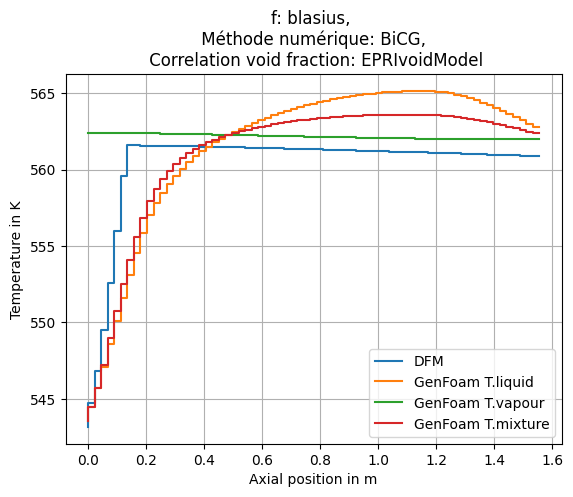

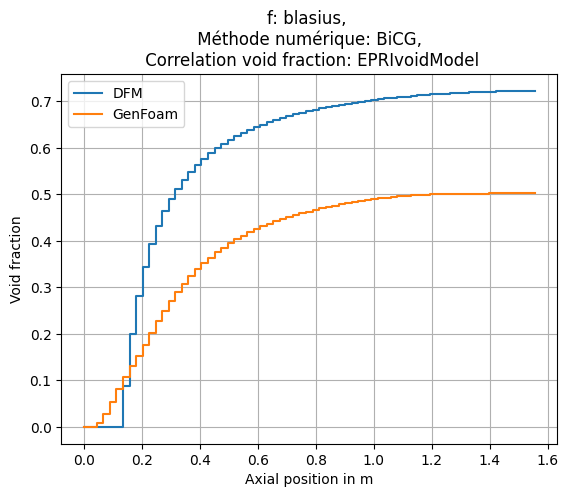

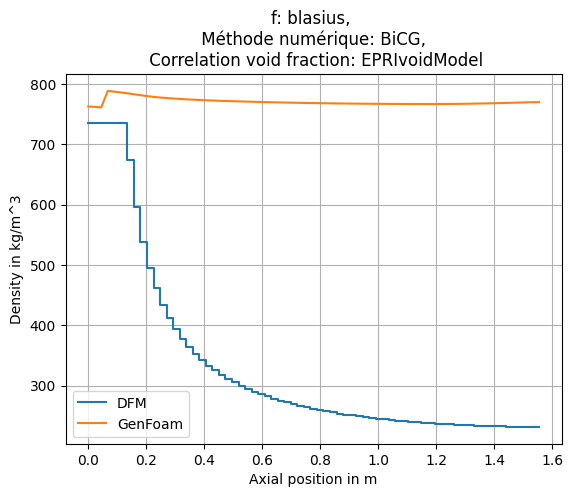

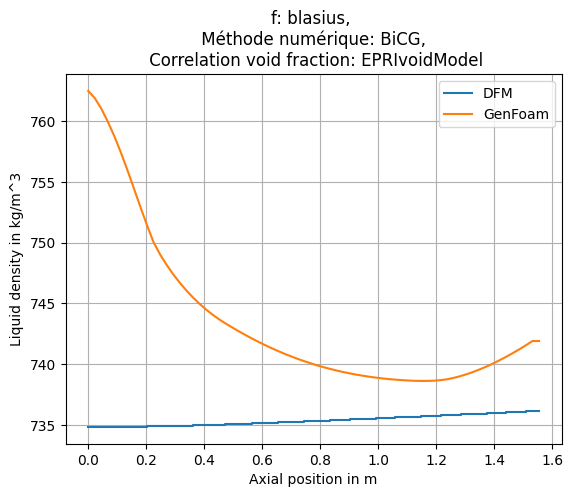

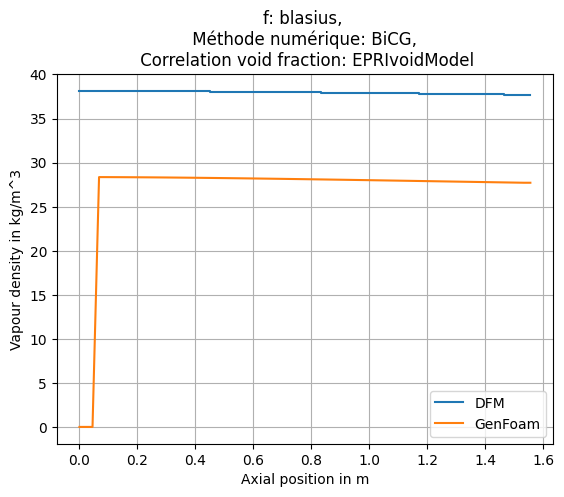

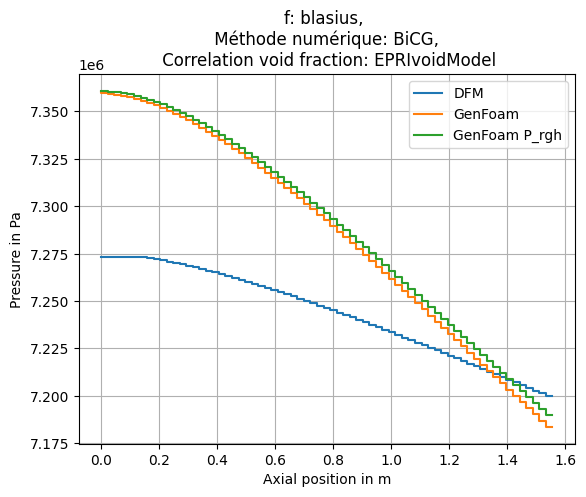

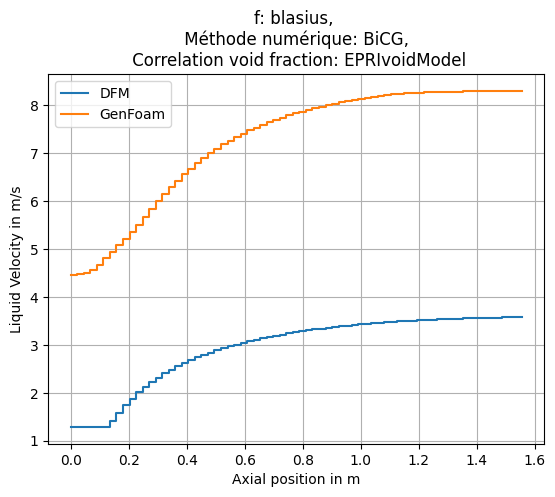

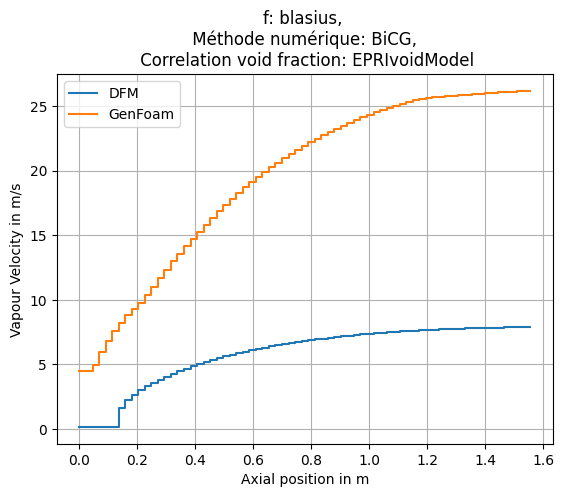

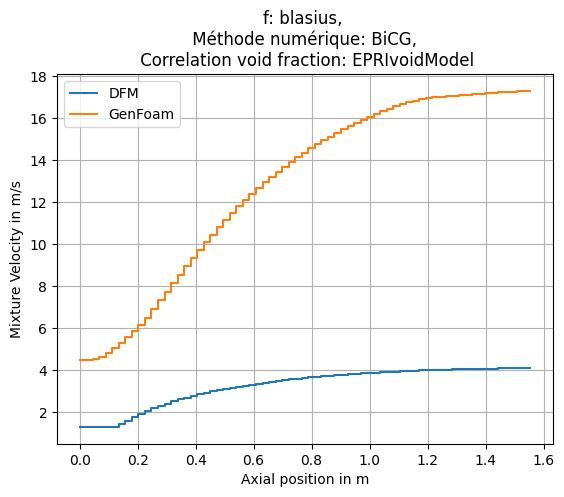

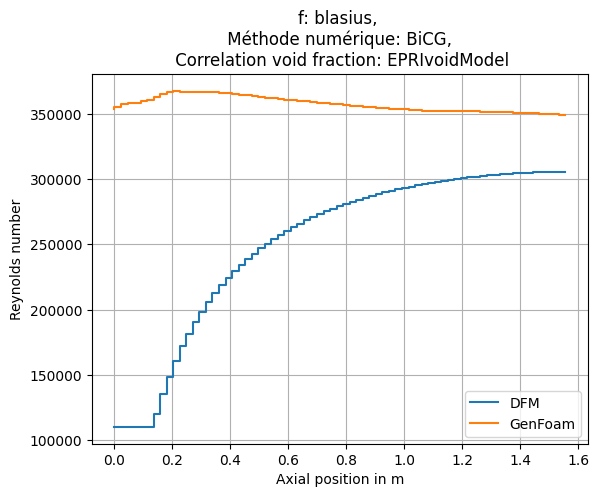

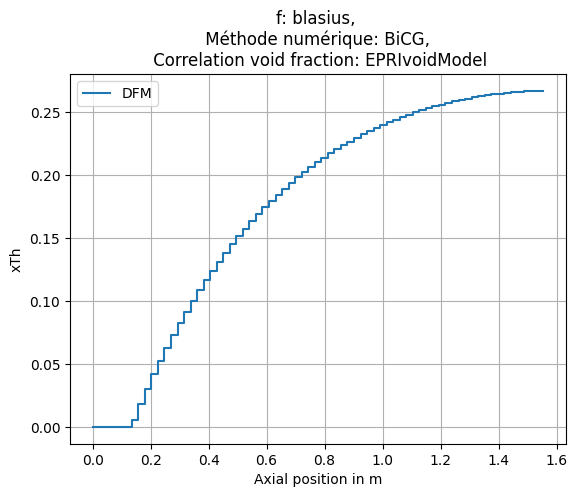

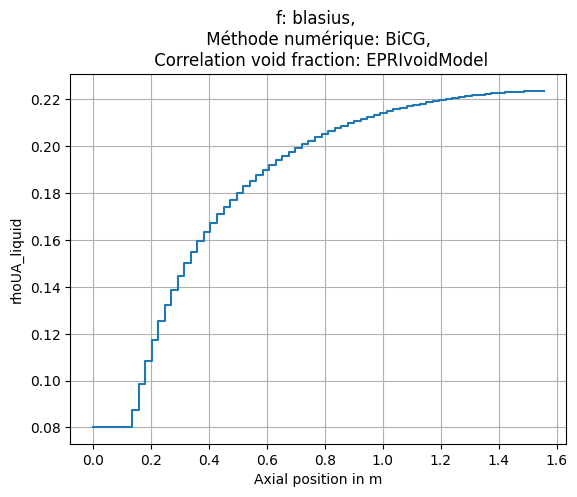

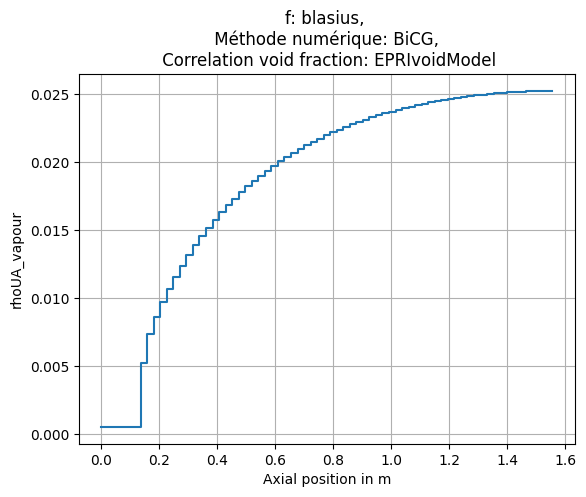

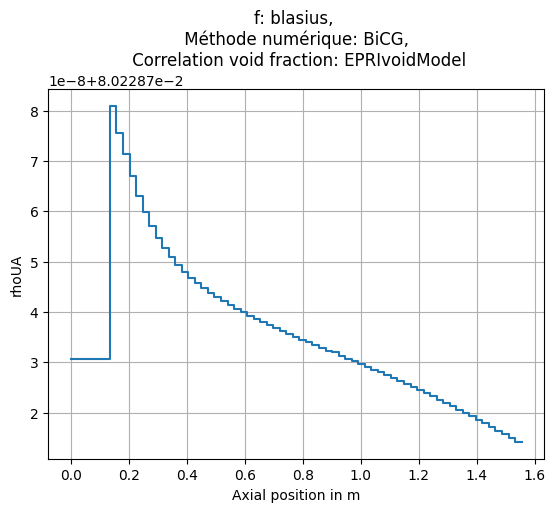

Umixture GeN-Foam: [ 4.46159     4.46397     4.46822     4.4970473   4.60165521  4.78562089
  5.02666138  5.29666854  5.57073317  5.84472138  6.13006415  6.48320158
  6.88859929  7.3038151   7.71843636  8.12881901  8.53318338  8.93077159
  9.32105906  9.70365313 10.07815797 10.44426705 10.80008009 11.14271573
 11.47146897 11.78691469 12.08959998 12.38018777 12.65938751 12.92769121
 13.18573702 13.43399134 13.67281313 13.90261434 14.12376111 14.33658201
 14.54144251 14.73852382 14.92817575 15.11059835 15.28600828 15.45456095
 15.61637376 15.77151641 15.92001572 16.06170779 16.19639375 16.32369798
 16.44295431 16.55331589 16.65372893 16.74288335 16.81961459 16.8829848
 16.93271292 16.9702056  17.00049171 17.02823958 17.0549524  17.08070155
 17.10536045 17.12904361 17.15159895 17.17310515 17.19356054 17.21281269
 17.23094506 17.2479809  17.26375761 17.28067995]
zlist Plotter: [0.         0.02253623 0.04507246 0.0676087  0.09014493 0.11268116
 0.13521739 0.15775362 0.18028986 0.20282609 0.

In [ ]:
plotter = GFPlotter([case0], rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\fluidRegion_MPHYS_Qfiss1_1555', "fluidRegion_MPHYS_Qfiss1_1555")
plotter.plotComparison()
#plotter.plotCase()
print(f'Umixture GeN-Foam: {plotter.U_mixture}')
print(f'zlist Plotter: {plotter.zList}')
print(f'len zListplotter: {len(plotter.zList)}')
print(f'zList convection: {case0.convection_sol.z_mesh}')
print(f'len z list convection {len(case0.convection_sol.z_mesh)}')
print(f'rhoua: {plotter.rhoUA}')  
print(f'rhoL GeN-Foam: {case0.convection_sol.rhoL[-1]}')
print(f'rhoG GeN-Foam: {case0.convection_sol.rhoG[-1]}')
print(f'rho GeN-Foam: {case0.convection_sol.rho[-1]}')


In [ ]:
print(f'volume_fracion_fuel: {(fuelRadius ** 2) / ( cladRadius ** 2)}')
print(f'volume_fracion_clad: {(np.pi *cladRadius ** 2) / waterRadius ** 2}')
q = [flowArea * Qfiss1[i] / (np.pi * fuelRadius ** 2) for i in range(len(Qfiss1))]
print(Qfiss1)
for i in range(len(Qfiss1)):
    print(q[i])

volume_fracion_fuel: 0.7444936713651985
volume_fracion_clad: 0.49415831517907005
[257362697.0467445, 462330502.4389329, 640796726.8034104, 799058502.8044009, 936876657.453143, 1049998322.3993744, 1128397084.9404068, 1135655778.3907356, 1094743013.2293603, 1043515262.6385702, 993917925.7216792, 945800891.3037366, 901868205.8875366, 861428450.9984155, 823396699.8979818, 786884646.587077, 752735243.5700626, 720517899.4315886, 689942351.8049228, 660817849.2266358, 633011621.5639107, 606430205.0460877, 581029757.9615227, 556713348.3311305, 533486578.645448, 510686754.3098468, 488934328.9188963, 468119475.872433, 448164827.4440383, 429004932.3157239, 410590879.855835, 392881985.31168854, 375842366.0653365, 359439874.49252266, 343644497.2511007, 328428399.7452366, 313765036.8412132, 299629441.88478446, 285997470.8095957, 272846202.31509244, 260153737.77755785, 247898689.9116983, 236060671.87695965, 224620119.420679, 213557957.3965169, 202855999.942342, 192496994.94444263, 182465757.87490538, 